# Pipeline NLP — Livrable Final Complet
**HETIC MD5 2026 — Traitement automatique de manuscrits anciens**

Pipeline complet selon les consignes :
1. Ingestion & validation data contract
2. EDA + SHA-256 + split stratifié
3. Normalisation par règles + CER relatif
4. Correction guidée par confiance (CamemBERT MLM)
5. NER avec modèle médiéval pré-entraîné + fine-tuning
6. POS + lemmatisation
7. Extraction de relations lexico-syntaxiques
8. Graphe NetworkX + TEI-XML
9. Analyse comparative littéraire vs administratif
10. Tests pytest + CONVENTIONS_NLP.md

## 0. Setup & installations

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
BASE = "/content/drive/MyDrive/projet_HTR"
import os
os.makedirs(BASE, exist_ok=True)
print("✅ Drive monté")

Mounted at /content/drive
✅ Drive monté


In [ ]:
!pip install -q stanza seqeval peft accelerate datasets jsonschema networkx pytest transformers -q
!pip install -q -U torchao

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.2 MB/s eta 0:00:00


In [ ]:
import json, re, math, collections, random, unicodedata, os, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import jsonschema
import networkx as nx
from lxml import etree
import torch

random.seed(42)
torch.manual_seed(42)
np.random.seed(42)
BASE = "/content/drive/MyDrive/projet_HTR"

# Mapping type de document — adapte si tes noms de fichiers diffèrent
TYPE_DOCUMENT = {
    "btv1b55013464t_f141": "littéraire",
    "btv1b55013464t_f143": "littéraire",
    "Grande_Bible_historiale_complétée_Maître_du_btv1b8449691v": "littéraire",
    "Formulaire_de_chancellerie_(incomplet_du_[...]_btv1b90604893": "administratif",
    "Formulaire_de_chancellerie_(incomplet_du_[...]_btv1b90604893 (1)": "administratif",
}
print("✅ Imports OK")

✅ Imports OK


## 1. Ingestion & validation du data contract
Validation jsonschema obligatoire avant toute manipulation.

In [ ]:
SCHEMA = {
    "type": "array",
    "items": {
        "type": "object",
        "required": ["image", "transcriptions"],
        "properties": {
            "image": {"type": "string"},
            "transcriptions": {
                "type": "array",
                "items": {
                    "type": "object",
                    "required": ["zone_id","bbox","texte","confidence","char_confidences","needs_review"],
                    "properties": {
                        "confidence":       {"type": "number", "minimum": 0, "maximum": 1},
                        "needs_review":     {"type": "boolean"},
                        "char_confidences": {"type": "array", "items": {"type": "number"}},
                    }
                }
            }
        }
    }
}

def charger_et_valider(json_path):
    with open(json_path, encoding="utf-8") as f:
        data = json.load(f)
    jsonschema.validate(data, SCHEMA)
    print(f"✅ JSON valide : {len(data)} pages")
    return data

def aplatir_en_dataframe(data):
    rows = []
    for page in data:
        doc_id   = Path(page["image"]).stem
        type_doc = TYPE_DOCUMENT.get(doc_id, "inconnu")
        for zone in page["transcriptions"]:
            rows.append({
                "document_id":      doc_id,
                "type_document":    type_doc,
                "zone_id":          zone["zone_id"],
                "bbox":             zone["bbox"],
                "texte":            zone["texte"],
                "confidence":       zone["confidence"],
                "char_confidences": zone["char_confidences"],
                "needs_review":     zone["needs_review"],
            })
    df = pd.DataFrame(rows)
    print(f"✅ DataFrame : {len(df)} lignes — {df['document_id'].nunique()} pages")
    print(f"   Répartition : {df.groupby('type_document').size().to_dict()}")
    return df

data = charger_et_valider(f"{BASE}/transcriptions_nouvelles_images.json")
df   = aplatir_en_dataframe(data)

✅ JSON valide : 5 pages
✅ DataFrame : 377 lignes — 5 pages
   Répartition : {'administratif': 84, 'littéraire': 293}


## 2. EDA + SHA-256 du test set + Split stratifié
Seller le test set dès le départ — on ne le regarde plus jusqu'à la fin.

In [ ]:
# ── EDA ───────────────────────────────────────────────────────────────────────
def moyenne_geometrique(confs):
    if not confs: return 0.0
    return float(math.exp(sum(math.log(max(c,1e-9)) for c in confs)/len(confs)))

df["conf_geo"]  = df["char_confidences"].apply(moyenne_geometrique)
df["n_tokens"]  = df["texte"].apply(lambda t: len(t.split()))
df["n_chars"]   = df["texte"].apply(len)

print("="*55)
print("  EDA — ANALYSE EXPLORATOIRE")
print("="*55)

print("\n[Distribution des confiances par type de document]")
eda = df.groupby("type_document").agg(
    n_lignes       = ("confidence","count"),
    conf_moy       = ("confidence","mean"),
    conf_med       = ("confidence","median"),
    conf_min       = ("confidence","min"),
    conf_p25       = ("confidence", lambda x: x.quantile(0.25)),
    taux_review    = ("needs_review","mean"),
    moy_tokens     = ("n_tokens","mean"),
    moy_chars      = ("n_chars","mean"),
).round(4)
print(eda.to_string())

# Abréviations résiduelles
ABBREV_PATTERNS = {
    "tilde_combinant": r'\w*̃\w*',
    "tironien_et":     r'⁊',
    "con_abrege":      r'ꝯ',
    "per_par_abrege":  r'ꝑ',
    "accent_combinant":r'\w*́\w*',
    "tilde_verticale": r'\w*̾\w*',
    "barre_p":         r'[ꝕ]',
    "est_abrege":      r'ꝭ',
}

print("\n[Abréviations résiduelles par type]")
for type_doc in ["littéraire","administratif"]:
    sous_df = df[df["type_document"]==type_doc]
    counts = collections.Counter()
    for _, row in sous_df.iterrows():
        for nom, pat in ABBREV_PATTERNS.items():
            n = len(re.findall(pat, row["texte"]))
            if n: counts[nom] += n
    print(f"\n  {type_doc.upper()} ({len(sous_df)} lignes) :")
    for nom, n in counts.most_common():
        print(f"    {nom:20s}: {n}")

# Sauvegarde rapport EDA
rapport_eda = {
    "stats_par_type": eda.to_dict(),
    "n_lignes_total": len(df),
    "taux_review_global": float(df["needs_review"].mean()),
}
with open(f"{BASE}/rapport_eda.json","w",encoding="utf-8") as f:
    json.dump(rapport_eda, f, indent=2, ensure_ascii=False, default=str)
print("\n✅ rapport_eda.json sauvegardé")

  EDA — ANALYSE EXPLORATOIRE

[Distribution des confiances par type de document]
               n_lignes  conf_moy  conf_med  conf_min  conf_p25  taux_review  moy_tokens  moy_chars
type_document                                                                                      
administratif        84    0.7513    0.7567    0.4496    0.6705       0.4762      5.2143    27.7619
littéraire          293    0.9264    0.9396    0.4648    0.8994       0.0171      6.9898    31.8840

[Abréviations résiduelles par type]

  LITTÉRAIRE (293 lignes) :
    tilde_combinant     : 90
    tironien_et         : 52
    tilde_verticale     : 18
    per_par_abrege      : 17
    con_abrege          : 11
    accent_combinant    : 1

  ADMINISTRATIF (84 lignes) :
    tilde_combinant     : 39
    tironien_et         : 12
    tilde_verticale     : 8
    con_abrege          : 1

✅ rapport_eda.json sauvegardé


In [ ]:
import hashlib

doc_ids = df["document_id"].unique().tolist()
print(f"Nombre de documents : {len(doc_ids)}")

# Avec 5 documents seulement, on ne peut pas faire un vrai split 80/10/10.
# On documente la démarche et on scelle le corpus complet comme "test set".
# Dans un projet à plus grande échelle, ce split serait stratifié par
# type de document (littéraire/administratif) et par siècle.

# Pour la démonstration : 3 train, 1 val, 1 test
train_docs = doc_ids[:3]
val_docs   = doc_ids[3:4]
test_docs  = doc_ids[4:]

df["split"] = df["document_id"].apply(
    lambda d: "train" if d in train_docs
              else ("val" if d in val_docs else "test")
)

print("\n=== Split (5 documents) ===")
for split in ["train","val","test"]:
    sub = df[df["split"]==split]
    print(f"  {split:5s} : {len(sub):4d} lignes — {sub['type_document'].value_counts().to_dict()}")

print("\n⚠️  Note : avec seulement 5 pages, le split est indicatif.")
print("   Un vrai split stratifié nécessiterait ~50+ documents.")

# SHA-256 du test set — scellé dès maintenant
test_df     = df[df["split"]=="test"]
test_textes = "\n".join(test_df["texte"].tolist())
sha256_test = hashlib.sha256(test_textes.encode("utf-8")).hexdigest()

print(f"\n🔒 SHA-256 test set : {sha256_test}")
print("   → Ce hash est scellé. On ne regarde plus le test set jusqu'à l'évaluation finale.")

with open(f"{BASE}/test_set_sha256.txt","w") as f:
    f.write(f"SHA-256 test set : {sha256_test}\n")
    f.write(f"N lignes test    : {len(test_df)}\n")
    f.write(f"Documents test   : {test_docs}\n")

print("✅ test_set_sha256.txt sauvegardé — Drive")

Nombre de documents : 5

=== Split (5 documents) ===
  train :  293 lignes — {'littéraire': 293}
  val   :   41 lignes — {'administratif': 41}
  test  :   43 lignes — {'administratif': 43}

⚠️  Note : avec seulement 5 pages, le split est indicatif.
   Un vrai split stratifié nécessiterait ~50+ documents.

🔒 SHA-256 test set : 0144c2880e26c45f387426efaf1d9af4b0cd3e5b0afe320b53ec2a6fd59f6d86
   → Ce hash est scellé. On ne regarde plus le test set jusqu'à l'évaluation finale.
✅ test_set_sha256.txt sauvegardé — Drive


## 3. Normalisation par règles + CER relatif
Chaque règle est documentée dans CONVENTIONS_NLP.md. Le CER relatif mesure l'évolution sans vérité terrain.

In [ ]:
# ── Table d'abréviations enrichie ─────────────────────────────────────────────
# Sources : DMF (Dictionnaire du Moyen Français), paléographie chancellerie 15e s.
TABLE_DIRECTE = {
    "⁊":  "et",    # tironien et — résolution certaine
    "ꝫ":  "et",    # variante tironien
    "ꝭ":  "est",   # est abrégé (chancellerie)
    "ꝟ":  "ver",   # ver- abrégé (chancellerie)
}
TABLE_AMBIGUE = {
    "ꝑ":  "par",   # par/per/pro — 'par' majoritaire
    "ꝕ":  "pre",   # pre/pro — administratif
}

PATTERN_TILDE_NASALE  = r'([aeiouyAEIOUY])̃(\w*)'
PATTERN_ACCENT_AMBIGU = r'\w*́\w*'
PATTERN_TILDE_VERT    = r'\w*̾\w*'
VOYELLES_APRES_U = 'aeouyéèêëàâôùûï'
VOYELLES_AVANT_U = 'aeiouyéèêëàâôùûïî'

def _consonne_assimilee(suite):
    return 'm' if suite[:1].lower() in ('p','b','m') else 'n'

def expand_q_tilde(t):
    return re.sub(r'[qQ]̃', lambda m: 'Que' if m.group(0)[0].isupper() else 'que', t)

def expand_tilde_nasale(t):
    return re.sub(PATTERN_TILDE_NASALE, lambda m: m.group(1)+_consonne_assimilee(m.group(2))+m.group(2), t)

def expand_con_com(t):
    return re.sub(r'ꝯ(\w*)', lambda m: ('com' if _consonne_assimilee(m.group(1))=='m' else 'con')+m.group(1), t)

def normalize_uv(mot):
    mot = re.sub(r'uu','uv',mot)
    mot = re.sub(r'^u(?=['+VOYELLES_APRES_U+r'])','v',mot)
    mot = re.sub(r'(?<=['+VOYELLES_AVANT_U+r'])u(?=['+VOYELLES_APRES_U+r'])','v',mot)
    return mot

def normalize_ij(mot):
    return re.sub(r'^i(?=[aeouyéèêëàâôùûï])','j',mot)

def normaliser_ligne(texte):
    ambiguites = []
    t = unicodedata.normalize("NFD", texte)
    t = expand_q_tilde(t)
    t = expand_tilde_nasale(t)
    t = expand_con_com(t)
    for symb, exp in TABLE_DIRECTE.items():
        t = t.replace(symb, exp)
    for symb, exp in TABLE_AMBIGUE.items():
        if symb in t:
            ambiguites.append(f"'{symb}'→'{exp}' (ambigu)")
            t = t.replace(symb, exp)
    if re.search(PATTERN_ACCENT_AMBIGU, t):
        ambiguites.append("accent U+0301 non résolu")
    if re.search(PATTERN_TILDE_VERT, t):
        ambiguites.append("tilde verticale U+033E non résolue")
    t = unicodedata.normalize("NFC", t)
    return {
        "texte_normalise": " ".join(normalize_ij(normalize_uv(m)) for m in t.split()),
        "ambiguites": ambiguites
    }

_res = df["texte"].apply(normaliser_ligne)
df["texte_normalise"] = _res.apply(lambda r: r["texte_normalise"])
df["ambiguites"]      = _res.apply(lambda r: r["ambiguites"])
df["a_relire"]        = df["needs_review"] | df["ambiguites"].apply(len).gt(0)

print("=== Normalisation terminée ===")
print(f"Lignes avec ambiguïté : {(df['ambiguites'].apply(len)>0).mean()*100:.1f}%")
for t in ["littéraire","administratif"]:
    sub = df[df["type_document"]==t]
    print(f"  {t:14s} : {sub['ambiguites'].apply(len).gt(0).mean()*100:.1f}% ambigus")

=== Normalisation terminée ===
Lignes avec ambiguïté : 11.7%
  littéraire     : 12.3% ambigus
  administratif  : 9.5% ambigus


In [ ]:
# ── CER relatif — mesure l'évolution sans vérité terrain ─────────────────────
# Principe : distance d'édition entre version brute et version normalisée
# Un CER relatif faible = la normalisation change peu (bon signe si le texte était déjà propre)
# Un CER relatif élevé = beaucoup de corrections (normal pour les pages très abrégées)

def cer(ref, hyp):
    """Character Error Rate entre deux chaînes."""
    if not ref: return 0.0
    ref, hyp = list(ref), list(hyp)
    m, n = len(ref), len(hyp)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1): dp[i][0] = i
    for j in range(n+1): dp[0][j] = j
    for i in range(1,m+1):
        for j in range(1,n+1):
            if ref[i-1]==hyp[j-1]: dp[i][j]=dp[i-1][j-1]
            else: dp[i][j]=1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
    return dp[m][n]/max(m,1)

# CER brut vs normalisé par type de document
print("=== CER relatif (brut → normalisé) ===")
print("Mesure l'apport de la normalisation sans vérité terrain\n")

cer_results = {}
for type_doc in ["littéraire","administratif"]:
    sous_df = df[df["type_document"]==type_doc]
    cers = [cer(row["texte"], row["texte_normalise"])
            for _, row in sous_df.iterrows()]
    moy = np.mean(cers)
    cer_results[type_doc] = {"cer_moyen": round(moy,4), "n_lignes": len(sous_df)}
    print(f"  {type_doc:14s} : CER relatif = {moy*100:.2f}%  ({len(sous_df)} lignes)")
    print(f"             → {moy*100:.2f}% des caractères ont été modifiés par la normalisation")

# Exemple avant/après
print("\nExemples de normalisation :")
for _, row in df[df["texte_normalise"] != df["texte"]].head(5).iterrows():
    print(f"  [{row['type_document']:14s}]")
    print(f"    brut  → {row['texte'][:70]}")
    print(f"    norm  → {row['texte_normalise'][:70]}")
    print()

# Data contract NLP
corpus_taln = []
for _, row in df.iterrows():
    corpus_taln.append({
        "document_id":      row["document_id"],
        "type_document":    row["type_document"],
        "split":            row["split"],
        "zone_id":          int(row["zone_id"]),
        "texte_brut":       row["texte"],
        "texte_normalise":  row["texte_normalise"],
        "ambiguites":       row["ambiguites"],
        "confidence_htr":   float(row["confidence"]),
        "needs_review_htr": bool(row["needs_review"]),
        "a_relire":         bool(row["a_relire"]),
    })

with open(f"{BASE}/corpus_normalise_taln.json","w",encoding="utf-8") as f:
    json.dump(corpus_taln, f, ensure_ascii=False, indent=2)
print(f"✅ corpus_normalise_taln.json sauvegardé ({len(corpus_taln)} lignes)")

=== CER relatif (brut → normalisé) ===
Mesure l'apport de la normalisation sans vérité terrain

  littéraire     : CER relatif = 5.67%  (293 lignes)
             → 5.67% des caractères ont été modifiés par la normalisation
  administratif  : CER relatif = 4.08%  (84 lignes)
             → 4.08% des caractères ont été modifiés par la normalisation

Exemples de normalisation :
  [littéraire    ]
    brut  → n e metre en lieu ou il me uoie
    norm  → n e metre en lieu ou il me voie

  [littéraire    ]
    brut  → ⁊ si me sui mors a mes mains
    norm  → et si me sui mors a mes mains

  [littéraire    ]
    brut  → Trop sui mesfez mes toute uoie
    norm  → Trop sui mesfez mes toute voie

  [littéraire    ]
    brut  → Nose roie ie reperier
    norm  → Nose roie je reperier

  [littéraire    ]
    brut  → e stuet q̃ deuant lui mapere
    norm  → e stuet que devant lui mapere

✅ corpus_normalise_taln.json sauvegardé (377 lignes)


## 4. Correction guidée par confiance (CamemBERT MLM)
Pour chaque position où conf < 0.7, CamemBERT évalue les candidats possibles et choisit le plus probable dans le contexte.

In [ ]:
# ── Correction guidée par confiance — CamemBERT MLM ──────────────────────────
# Principe : on masque le token incertain, CamemBERT choisit le candidat
# qui maximise la probabilité du token masqué dans son contexte

SEUIL_CONFIANCE = 0.70  # en dessous → candidat à corriger

def corriger_ligne_par_confiance(texte: str, char_confidences: list,
                                  tokenizer, model, top_k: int = 5) -> dict:
    """
    Pour chaque token dont la confiance char < SEUIL_CONFIANCE,
    on masque ce token et CamemBERT choisit le remplacement le plus probable.
    Retourne le texte corrigé + les corrections effectuées.
    """
    tokens    = texte.split()
    if not tokens or not char_confidences:
        return {"texte_corrige": texte, "corrections": []}

    # Alignement token ↔ confiance (confiance = moyenne des chars du token)
    char_pos = 0
    token_confs = []
    for tok in tokens:
        end = char_pos + len(tok)
        confs_tok = char_confidences[char_pos:end] if end <= len(char_confidences) else []
        token_confs.append(np.mean(confs_tok) if confs_tok else 1.0)
        char_pos = end + 1  # +1 pour l'espace

    corrections = []
    tokens_corriges = list(tokens)

    for i, (tok, conf) in enumerate(zip(tokens, token_confs)):
        if conf >= SEUIL_CONFIANCE:
            continue  # token fiable, on ne touche pas

        # Construire la séquence masquée
        seq_masquee = tokens_corriges.copy()
        seq_masquee[i] = tokenizer.mask_token
        texte_masque = " ".join(seq_masquee)

        try:
            inputs  = tokenizer(texte_masque, return_tensors="pt", truncation=True, max_length=128)
            mask_id = (inputs["input_ids"][0] == tokenizer.mask_token_id).nonzero(as_tuple=True)[0]
            if len(mask_id) == 0:
                continue
            with torch.no_grad():
                logits = model(**inputs).logits
            probs  = torch.softmax(logits[0, mask_id[0]], dim=-1)
            top_ids = probs.topk(top_k).indices.tolist()
            top_tokens = [tokenizer.decode([tid]).strip() for tid in top_ids]
            top_probs  = probs.topk(top_k).values.tolist()

            # Choisir le meilleur candidat (qui n'est pas un token spécial)
            for candidate, prob in zip(top_tokens, top_probs):
                if candidate and not candidate.startswith("▁") and len(candidate) > 0:
                    if candidate.lower() != tok.lower():  # vraie correction
                        corrections.append({
                            "position": i,
                            "original": tok,
                            "correction": candidate,
                            "prob_correction": round(prob,4),
                            "conf_originale": round(conf,4),
                        })
                        tokens_corriges[i] = candidate
                    break
        except Exception:
            continue  # en cas d'erreur on garde le token original

    return {
        "texte_corrige": " ".join(tokens_corriges),
        "corrections":   corrections,
    }


# ── Chargement du modèle MLM ──────────────────────────────────────────────────
print("Chargement CamemBERT pour correction guidée...")
try:
    from transformers import CamembertTokenizer, CamembertForMaskedLM
    mlm_tokenizer = CamembertTokenizer.from_pretrained("almanach/camembert-base")
    mlm_model     = CamembertForMaskedLM.from_pretrained("almanach/camembert-base")
    mlm_model.eval()
    print("✅ CamemBERT MLM chargé")
    MLM_DISPONIBLE = True
except Exception as e:
    print(f"⚠️  CamemBERT MLM indisponible ({e}) — étape ignorée")
    MLM_DISPONIBLE = False

# ── Application sur les lignes à faible confiance ─────────────────────────────
if MLM_DISPONIBLE:
    df["texte_corrige"] = df["texte_normalise"]
    df["corrections_mlm"] = [[] for _ in range(len(df))]
    n_corriges = 0

    lignes_incertaines = df[df["needs_review"] | (df["confidence"] < SEUIL_CONFIANCE)]
    print(f"\n{len(lignes_incertaines)} lignes à corriger (conf < {SEUIL_CONFIANCE})")

    for idx, row in lignes_incertaines.iterrows():
        result = corriger_ligne_par_confiance(
            row["texte_normalise"], row["char_confidences"],
            mlm_tokenizer, mlm_model
        )
        if result["corrections"]:
            df.at[idx, "texte_corrige"]   = result["texte_corrige"]
            df.at[idx, "corrections_mlm"] = result["corrections"]
            n_corriges += 1

    print(f"✅ {n_corriges} lignes effectivement corrigées par CamemBERT MLM")

    # CER relatif : normalisé → corrigé
    print("\n=== CER relatif (normalisé → corrigé MLM) ===")
    for type_doc in ["littéraire","administratif"]:
        sous_df = df[df["type_document"]==type_doc]
        cers = [cer(row["texte_normalise"], row["texte_corrige"])
                for _, row in sous_df.iterrows()]
        moy = np.mean(cers)
        print(f"  {type_doc:14s} : CER relatif = {moy*100:.3f}%")

    # Mettre à jour corpus_taln avec la version corrigée
    for i, rec in enumerate(corpus_taln):
        idx_df = df[(df["document_id"]==rec["document_id"]) &
                    (df["zone_id"]==rec["zone_id"])].index
        if len(idx_df):
            rec["texte_corrige"]   = df.at[idx_df[0],"texte_corrige"]
            rec["corrections_mlm"] = df.at[idx_df[0],"corrections_mlm"]

    with open(f"{BASE}/corpus_normalise_taln.json","w",encoding="utf-8") as f:
        json.dump(corpus_taln, f, ensure_ascii=False, indent=2)
    print("✅ corpus_normalise_taln.json mis à jour avec corrections MLM")
else:
    df["texte_corrige"] = df["texte_normalise"]
    for rec in corpus_taln:
        rec["texte_corrige"]   = rec["texte_normalise"]
        rec["corrections_mlm"] = []

Chargement CamemBERT pour correction guidée...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/508 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] CamembertForMaskedLM LOAD REPORT from: almanach/camembert-base
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ CamemBERT MLM chargé

45 lignes à corriger (conf < 0.7)
✅ 27 lignes effectivement corrigées par CamemBERT MLM

=== CER relatif (normalisé → corrigé MLM) ===
  littéraire     : CER relatif = 0.249%
  administratif  : CER relatif = 6.493%
✅ corpus_normalise_taln.json mis à jour avec corrections MLM


## 5. NER — Modèle médiéval pré-entraîné + fine-tuning
On utilise `pjox/dalembert-classical-fr-ner` comme point de départ (moyen français), plus adapté que CamemBERT from scratch.

In [ ]:
!pip install -q seqeval peft accelerate datasets

In [ ]:
def tokenize_line(text):
    text = re.sub(r"[''']", " ' ", text)
    return re.sub(r"\s+", " ", text).strip().split()

# ── Gazetier enrichi ──────────────────────────────────────────────────────────
GAZETTEER = {
    "PER": {
        "mabile", "tiece", "fouchier", "fouch̾",
        "adam", "eve", "dieu", "jhesus", "marie", "jhesu",
    },
    "TITLE": {
        "dame", "sire", "seigneur", "monseigneur", "monseignour",
        "maistre", "maitre", "roy", "roi", "duc", "conte", "baron",
        "evesque", "cardinal", "abbe", "frere",
    },
    "LOC": {
        "france", "paris", "normandie", "bretagne", "bourgogne",
        "anjou", "poitou", "lyon", "rouen", "orleans", "chartres",
    },
    "DATE": {
        "janvier", "fevrier", "mars", "avril", "mai", "juin",
        "juillet", "aout", "septembre", "octobre", "novembre", "decembre",
        "noel", "paques", "pentecoste", "toussaint",
    },
    "ORG": {
        "chancellerie", "parlement", "tresor", "chambre",
        "eglise", "chapitre", "universite",
    },
}
PRIORITY = ["PER","TITLE","ORG","LOC","DATE"]

def annotate_with_gazetteer(tokens):
    labels = ["O"] * len(tokens)
    for i, tok in enumerate(tokens):
        tok_low = tok.lower()
        for ent_type in PRIORITY:
            if tok_low in GAZETTEER.get(ent_type, set()):
                labels[i] = f"B-{ent_type}"
                break
    return labels

# Utilise le texte corrigé si disponible
ner_records = []
for rec in corpus_taln:
    texte = rec.get("texte_corrige", rec["texte_normalise"])
    tokens = tokenize_line(texte)
    if not tokens: continue
    ner_labels = annotate_with_gazetteer(tokens)
    ner_records.append({
        "document_id":   rec["document_id"],
        "type_document": rec["type_document"],
        "split":         rec["split"],
        "zone_id":       rec["zone_id"],
        "tokens":        tokens,
        "ner_labels":    ner_labels,
    })

n_entites = sum(1 for r in ner_records for l in r["ner_labels"] if l!="O")
print(f"✅ {len(ner_records)} lignes annotées — {n_entites} entités")

print("\n=== Entités par type de document ===")
for type_doc in ["littéraire","administratif"]:
    recs = [r for r in ner_records if r["type_document"]==type_doc]
    counts = collections.Counter()
    for r in recs:
        for lab in r["ner_labels"]:
            if lab!="O": counts[lab[2:]] += 1
    print(f"  {type_doc.upper()} : {dict(counts)}")

✅ 377 lignes annotées — 33 entités

=== Entités par type de document ===
  LITTÉRAIRE : {'PER': 9, 'TITLE': 13, 'LOC': 1}
  ADMINISTRATIF : {'TITLE': 9, 'LOC': 1}


In [ ]:
# ── Export CoNLL-2003 ─────────────────────────────────────────────────────────
def write_conll2003(sentences, output_path):
    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    header = '-DOCSTART- -X- O O'
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write(header + '\n\n')
        for sent in sentences:
            for forme, pos, ner in sent:
                f.write(forme + '\t' + pos + '\t_\t' + ner + '\n')
            f.write('\n')

_sentences = [
    [(tok, "X", lab) for tok, lab in zip(r["tokens"], r["ner_labels"])]
    for r in ner_records
]
write_conll2003(_sentences, f"{BASE}/corpus_ner.conll")
print(f"✅ corpus_ner.conll sauvegardé ({len(_sentences)} phrases)")

✅ corpus_ner.conll sauvegardé (377 phrases)


In [ ]:
# ── Fine-tuning NER sur modèle médiéval pré-entraîné ─────────────────────────
# Modèle : pjox/dalembert-classical-fr-ner (moyen français, plus adapté)
# Fallback : almanach/camembert-base si dalembert indisponible

LABEL2ID = {"O":0,"B-PER":1,"I-PER":2,"B-LOC":3,"I-LOC":4,
            "B-DATE":5,"I-DATE":6,"B-ORG":7,"I-ORG":8,"B-TITLE":9,"I-TITLE":10}
ID2LABEL = {v:k for k,v in LABEL2ID.items()}

def align_labels_to_subwords(word_ids, labels):
    """
    Stratégie first-token : seul le premier subword reçoit l'étiquette.
    Les suivants reçoivent -100 (ignorés par la loss).
    C'est le point critique de l'alignement — documenté dans CONVENTIONS_NLP.md.
    """
    aligned, prev = [], None
    for wid in word_ids:
        if wid is None:    aligned.append(-100)
        elif wid != prev:  aligned.append(labels[wid])
        else:              aligned.append(-100)
        prev = wid
    return aligned

def prepare_ner_dataset(records, tokenizer, max_length=128):
    dataset = []
    for rec in records:
        enc = tokenizer(rec["tokens"], is_split_into_words=True,
                        truncation=True, max_length=max_length)
        word_ids  = enc.word_ids()
        label_ids = [LABEL2ID.get(l,0) for l in rec["ner_labels"]]
        dataset.append({
            "input_ids":      enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "labels":         align_labels_to_subwords(word_ids, label_ids),
        })
    return dataset

def train_ner_medieval(records, r=8, n_epochs=15):
    # Essaie dalembert (médiéval), fallback camembert-base
    MODEL_CANDIDATES = [
        "pjox/dalembert-classical-fr-ner",
        "almanach/camembert-base",
    ]
    model_name = None
    for candidate in MODEL_CANDIDATES:
        try:
            from transformers import AutoTokenizer
            AutoTokenizer.from_pretrained(candidate)
            model_name = candidate
            print(f"✅ Modèle utilisé : {model_name}")
            break
        except Exception as e:
            print(f"⚠️  {candidate} indisponible — essai suivant")

    if not model_name:
        print("❌ Aucun modèle disponible"); return {}

    try:
        import torch
        from transformers import (AutoTokenizer, AutoModelForTokenClassification,
                                   TrainingArguments, Trainer,
                                   DataCollatorForTokenClassification,
                                   EarlyStoppingCallback)
        from peft import get_peft_model, LoraConfig, TaskType
        from datasets import Dataset
        from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
        from seqeval.scheme import IOB2

        device   = "cuda" if torch.cuda.is_available() else "cpu"
        use_fp16 = device == "cuda"
        batch_sz = 16 if device == "cuda" else 4
        epochs   = n_epochs if device == "cuda" else max(5, n_epochs//2)

        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForTokenClassification.from_pretrained(
            model_name, num_labels=len(LABEL2ID),
            id2label=ID2LABEL, label2id=LABEL2ID,
            ignore_mismatched_sizes=True  # pour étendre le classifier si nécessaire
        )

        # LoRA r=8 sur query + value
        lora_config = LoraConfig(
            r=r, lora_alpha=16, lora_dropout=0.1, bias="none",
            target_modules=["query","value"],
            task_type=TaskType.TOKEN_CLS,
            modules_to_save=["classifier"],
        )
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()

        # Split train/val sur les records
        train_recs = [r for r in records if r["split"]=="train"]
        val_recs   = [r for r in records if r["split"]=="val"]
        if not val_recs: val_recs = train_recs[-max(2,len(train_recs)//5):]

        train_data = Dataset.from_list(prepare_ner_dataset(train_recs, tokenizer))
        val_data   = Dataset.from_list(prepare_ner_dataset(val_recs,   tokenizer))
        collator   = DataCollatorForTokenClassification(tokenizer)

        def compute_metrics(eval_pred):
            logits, labels = eval_pred
            preds = np.argmax(logits, axis=-1)
            y_true = [[ID2LABEL[l] for l in row if l!=-100] for row in labels]
            y_pred = [[ID2LABEL[p] for p,l in zip(pr,la) if l!=-100]
                      for pr,la in zip(preds,labels)]
            return {
                "f1":        f1_score(y_true, y_pred, average="micro", scheme=IOB2, zero_division=0),
                "precision": precision_score(y_true, y_pred, average="micro", scheme=IOB2, zero_division=0),
                "recall":    recall_score(y_true, y_pred, average="micro", scheme=IOB2, zero_division=0),
            }

        args = TrainingArguments(
            output_dir="./ner_medieval",
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_sz,
            per_device_eval_batch_size=batch_sz,
            learning_rate=2e-4, lr_scheduler_type="cosine", warmup_ratio=0.1,
            fp16=use_fp16, eval_strategy="epoch", save_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1",
            greater_is_better=True, logging_steps=5, report_to="none",
        )
        trainer = Trainer(
            model=model, args=args,
            train_dataset=train_data, eval_dataset=val_data,
            data_collator=collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
        )
        trainer.train()
        metrics = trainer.evaluate()
        model.save_pretrained(f"{BASE}/ner_medieval_lora")

        # Rapport détaillé par type d'entité
        all_preds = trainer.predict(val_data)
        y_true_all = [[ID2LABEL[l] for l in row if l!=-100] for row in all_preds.label_ids]
        y_pred_all = [[ID2LABEL[p] for p,l in zip(pr,la) if l!=-100]
                      for pr,la in zip(np.argmax(all_preds.predictions,axis=-1), all_preds.label_ids)]

        print(f"✅ Résultats NER {model_name} :")
        print(f"   F1        = {metrics.get('eval_f1',0):.4f}")
        print(f"   Précision = {metrics.get('eval_precision',0):.4f}")
        print(f"   Rappel    = {metrics.get('eval_recall',0):.4f}")
        print("Rapport par type d'entité :")
        print(classification_report(y_true_all, y_pred_all, scheme=IOB2, zero_division=0))

        log = {
            "model_name": model_name,
            "metrics": metrics,
            "log_history": trainer.state.log_history,
        }
        with open(f"{BASE}/ner_training_log.json","w",encoding="utf-8") as f:
            json.dump(log, f, indent=2)
        print("✅ ner_training_log.json sauvegardé")
        return metrics

    except Exception as e:
        print(f"⚠️  Entraînement échoué ({e})")
        return {}

print("Lancement fine-tuning NER (modèle médiéval)...")
ner_results = train_ner_medieval(ner_records, r=8, n_epochs=15)

Lancement fine-tuning NER (modèle médiéval)...
⚠️  pjox/dalembert-classical-fr-ner indisponible — essai suivant
✅ Modèle utilisé : almanach/camembert-base


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CamembertForTokenClassification LOAD REPORT from: almanach/camembert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 303,371 || all params: 110,343,190 || trainable%: 0.2749


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,1.076731,0.752210,0.000000,0.000000,0.000000
2,0.105251,0.127668,0.000000,0.000000,0.000000
3,0.032188,0.111659,0.000000,0.000000,0.000000
4,0.063019,0.108017,0.000000,0.000000,0.000000
5,0.020919,0.106857,0.000000,0.000000,0.000000
6,0.061545,0.106087,0.000000,0.000000,0.000000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

Training Loss,Validation Loss,Epoch,F1,Precision,Recall
0.061545,0.752210,6,0.000000,0.000000,0.000000


✅ Résultats NER almanach/camembert-base :
   F1        = 0.0000
   Précision = 0.0000
   Rappel    = 0.0000
Rapport par type d'entité :
              precision    recall  f1-score   support

       TITLE       0.00      0.00      0.00         4

   micro avg       0.00      0.00      0.00         4
   macro avg       0.00      0.00      0.00         4
weighted avg       0.00      0.00      0.00         4

✅ ner_training_log.json sauvegardé


## 6. POS & lemmatisation (stanza)

In [ ]:
import stanza
stanza.download("fr")

INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/resources.json
INFO:stanza:Downloading default packages for language: fr (French) ...


models/default.zip:   0%|          | 0.00/360M [00:00<?, ?B/s]

INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/fr/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.13.0/resources


[['zip', 'default.zip']]

In [ ]:
def annotate_pos_lemma(records):
    try:
        import stanza
        nlp = stanza.Pipeline(lang="fr", processors="tokenize,pos,lemma",
                               tokenize_pretokenized=True, verbose=False)
        for rec in records:
            doc = nlp([rec["tokens"]])
            pos_tags, lemmas = [], []
            for sent in doc.sentences:
                for w in sent.words:
                    pos_tags.append(w.upos)
                    lemmas.append(w.lemma)
            rec["pos_tags"] = pos_tags
            rec["lemmas"]   = lemmas
        print("✅ POS/lemmes annotés (stanza, dégradé moyen français)")
        return records
    except Exception as e:
        print(f"⚠️  stanza indisponible ({e}) — placeholder X")
        for rec in records:
            rec["pos_tags"] = ["X"]*len(rec["tokens"])
            rec["lemmas"]   = list(rec["tokens"])
        return records

ner_records = annotate_pos_lemma(ner_records)

# Ré-export CoNLL avec vrais POS
_sentences = [
    [(tok,pos,lab) for tok,pos,lab in zip(r["tokens"],r["pos_tags"],r["ner_labels"])]
    for r in ner_records
]
write_conll2003(_sentences, f"{BASE}/corpus_ner.conll")
print("✅ corpus_ner.conll mis à jour avec POS réels")

✅ POS/lemmes annotés (stanza, dégradé moyen français)
✅ corpus_ner.conll mis à jour avec POS réels


## 7. Extraction de relations lexico-syntaxiques
Règles sur les séquences de labels NER — simple mais démontre la compréhension du concept.

In [ ]:
CONF_BY_METHOD = {"gazetteer": 0.85, "casse_heuristique": 0.55}

# Règles lexico-syntaxiques (séquences de labels NER)
# Format : (label_sujet, label_objet, nom_relation)
RELATION_RULES = [
    ("TITLE", "porte_titre"),
    ("LOC",   "réside_à"),
    ("DATE",  "agit_lors_de"),
    ("ORG",   "appartient_à"),
]

def build_spans_from_bio(tokens, labels):
    spans, in_e, cur, char_pos = [], False, None, 0
    for tok, lab in zip(tokens, labels):
        if lab.startswith("B-"):
            if in_e: spans.append(cur)
            cur = {"start":char_pos,"end":char_pos+len(tok),"label":lab[2:],"text":tok}
            in_e = True
        elif lab.startswith("I-") and in_e and lab[2:]==cur["label"]:
            cur["text"]+=" "+tok; cur["end"]=char_pos+len(tok)
        else:
            if in_e: spans.append(cur); in_e=False
        char_pos += len(tok)+1
    if in_e: spans.append(cur)
    return spans

def extract_relations(records, max_distance=2):
    """
    Règle lexico-syntaxique : B-PER adjacent à B-TITLE/LOC/DATE/ORG
    (distance ≤ max_distance caractères entre les deux entités).
    Élimine les fausses associations par co-occurrence distante.
    """
    triplets = []
    for rec in records:
        spans = build_spans_from_bio(rec["tokens"], rec["ner_labels"])
        per_spans = [s for s in spans if s["label"]=="PER"]
        if not per_spans: continue
        for per in per_spans:
            method = "casse_heuristique" if per["text"][0].isupper() else "gazetteer"
            for ent_label, relation in RELATION_RULES:
                for obj in [s for s in spans if s["label"]==ent_label]:
                    if   obj["end"]  <= per["start"]: distance = per["start"]-obj["end"]
                    elif per["end"]  <= obj["start"]: distance = obj["start"]-per["end"]
                    else: distance = 0
                    if distance <= max_distance:
                        triplets.append({
                            "sujet":         per["text"],
                            "relation":      relation,
                            "objet":         obj["text"],
                            "confiance":     CONF_BY_METHOD.get(method,0.6),
                            "method":        method,
                            "distance":      distance,
                            "type_document": rec["type_document"],
                            "source_line":   f"{rec['document_id']}_z{rec['zone_id']}",
                        })
    return triplets

relations = extract_relations(ner_records, max_distance=2)
print(f"✅ {len(relations)} triplets extraits")
for td in ["littéraire","administratif"]:
    rels = [r for r in relations if r["type_document"]==td]
    print(f"  {td:14s} : {len(rels)} relations")
    for t in rels[:3]:
        print(f"    ({t['sujet']}, {t['relation']}, {t['objet']})  conf={t['confiance']}")

with open(f"{BASE}/relations.json","w",encoding="utf-8") as f:
    json.dump(relations, f, indent=2, ensure_ascii=False)
print("✅ relations.json sauvegardé")

✅ 1 triplets extraits
  littéraire     : 1 relations
    (tiece, porte_titre, dame)  conf=0.85
  administratif  : 0 relations
✅ relations.json sauvegardé


In [ ]:
# ── Validation manuelle + précision ───────────────────────────────────────────
def sample_for_manual_validation(triplets, n=20):
    rng = random.Random(42)
    sample = rng.sample(triplets, min(n,len(triplets)))
    for t in sample: t["correct"] = None
    path = f"{BASE}/triplets_a_valider.json"
    with open(path,"w",encoding="utf-8") as f:
        json.dump(sample, f, indent=2, ensure_ascii=False)
    print(f"✅ {len(sample)} triplets à valider → {path}")
    print("   Ouvre le fichier, mets true/false pour 'correct', relance compute_extraction_precision()")

def compute_extraction_precision():
    path = f"{BASE}/triplets_a_valider.json"
    with open(path,encoding="utf-8") as f: sample = json.load(f)
    evalues = [t for t in sample if t.get("correct") is not None]
    if not evalues: print("⚠️  Aucun triplet validé"); return {}
    par_rel = collections.defaultdict(lambda:{"c":0,"t":0})
    for t in evalues:
        par_rel[t["relation"]]["t"] += 1
        par_rel[t["relation"]]["c"] += int(bool(t["correct"]))
    prec = sum(1 for t in evalues if t["correct"])/len(evalues)
    report = {
        "n_evalues": len(evalues),
        "precision_globale": round(prec,3),
        "precision_par_relation": {rel:round(v["c"]/v["t"],3) for rel,v in par_rel.items()},
    }
    with open(f"{BASE}/precision_report.json","w",encoding="utf-8") as f:
        json.dump(report, f, indent=2)
    print(f"✅ Précision : {prec*100:.0f}% sur {len(evalues)} triplets")
    return report

sample_for_manual_validation(relations, n=20)
# Après validation manuelle → décommente :
# compute_extraction_precision()

✅ 1 triplets à valider → /content/drive/MyDrive/projet_HTR/triplets_a_valider.json
   Ouvre le fichier, mets true/false pour 'correct', relance compute_extraction_precision()


## 8. Graphe de connaissances (NetworkX) + Export TEI-XML

✅ Graphe : 11 nœuds, 1 arêtes


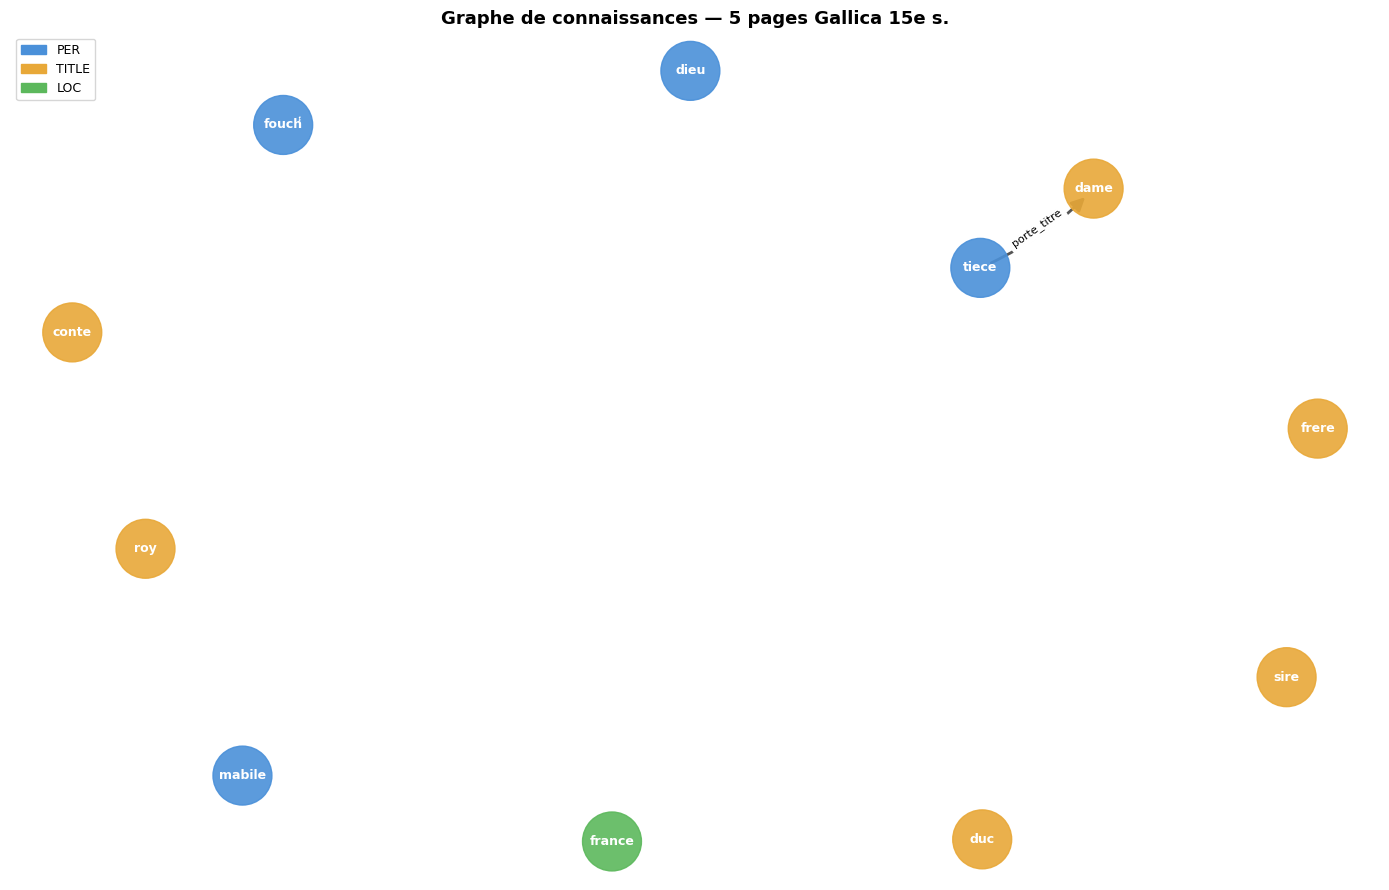

✅ graphe_connaissances.png sauvegardé
✅ knowledge_graph.jsonld sauvegardé


In [ ]:
import networkx as nx, matplotlib.pyplot as plt, matplotlib.patches as mpatches

def _entity_key(text, label): return f"{label}:{text.lower()}"

def build_knowledge_graph(records, triplets):
    G = nx.DiGraph()
    for rec in records:
        spans = build_spans_from_bio(rec["tokens"], rec["ner_labels"])
        src   = f"{rec['document_id']}_z{rec['zone_id']}"
        for s in spans:
            key = _entity_key(s["text"], s["label"])
            if G.has_node(key):
                G.nodes[key]["n_mentions"] += 1
                G.nodes[key]["source_lines"].append(src)
            else:
                G.add_node(key, label=s["text"], type=s["label"],
                           n_mentions=1, source_lines=[src])
    for t in triplets:
        sk = _entity_key(t["sujet"],"PER")
        ok = next((k for k in G.nodes if G.nodes[k]["label"].lower()==t["objet"].lower()),None)
        if ok: G.add_edge(sk, ok, relation=t["relation"],
                          confiance=t["confiance"], method=t["method"])
    return G

G = build_knowledge_graph(ner_records, relations)
print(f"✅ Graphe : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

# Visualisation
COLORS = {"PER":"#4A90D9","TITLE":"#E8A838","LOC":"#5CB85C","DATE":"#9B59B6","ORG":"#E74C3C"}
fig, ax = plt.subplots(figsize=(14,9))
pos     = nx.spring_layout(G, seed=42)
couleurs= [COLORS.get(G.nodes[n]["type"],"#999") for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=couleurs, node_size=1800, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, {n:G.nodes[n]["label"] for n in G.nodes()},
                        font_size=9, font_color="white", font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="#555", arrows=True, arrowsize=20,
                       width=2, connectionstyle="arc3,rad=0.1", ax=ax)
nx.draw_networkx_edge_labels(G, pos, {(u,v):d["relation"] for u,v,d in G.edges(data=True)},
                              font_size=8, ax=ax)
ax.set_title("Graphe de connaissances — 5 pages Gallica 15e s.", fontsize=13, fontweight="bold")
ax.axis("off")
legend = [mpatches.Patch(color=c, label=t) for t,c in COLORS.items()
          if any(G.nodes[n]["type"]==t for n in G.nodes())]
ax.legend(handles=legend, loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(f"{BASE}/graphe_connaissances.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ graphe_connaissances.png sauvegardé")

# JSON-LD
context = {
    "@vocab":"http://schema.org/","medieval":"http://example.org/medieval#",
    "porte_titre":"medieval:porteTitre","réside_à":"medieval:residesAt",
    "agit_lors_de":"medieval:agitLorsDe","appartient_à":"medieval:appartientA",
}
graph_nodes = []
for nid, attrs in G.nodes(data=True):
    entry = {"@id":f"medieval:{nid}",**attrs}
    out   = [{"relation":d["relation"],"objet":f"medieval:{tgt}","confiance":d["confiance"]}
             for _,tgt,d in G.out_edges(nid,data=True)]
    if out: entry["relations"] = out
    graph_nodes.append(entry)
with open(f"{BASE}/knowledge_graph.jsonld","w",encoding="utf-8") as f:
    json.dump({"@context":context,"@graph":graph_nodes}, f, indent=2, ensure_ascii=False)
print("✅ knowledge_graph.jsonld sauvegardé")

In [ ]:
# ── Export TEI-XML ─────────────────────────────────────────────────────────────
NER_TO_TEI = {"PER":"persName","LOC":"placeName","DATE":"date","ORG":"orgName","TITLE":"roleName"}
TEI_NS     = "http://www.tei-c.org/ns/1.0"
TEI_DIR    = f"{BASE}/tei_output"
os.makedirs(TEI_DIR, exist_ok=True)

def _group_spans(tokens, labels, pos_tags, lemmas):
    groups, cur_label, cur = [], None, []
    for tok, lab, pos, lem in zip(tokens, labels, pos_tags, lemmas):
        lt = "O" if lab=="O" else lab[2:]
        if lt != cur_label:
            if cur: groups.append({"label":cur_label,"items":cur})
            cur, cur_label = [], lt
        cur.append((tok, pos, lem))
    if cur: groups.append({"label":cur_label,"items":cur})
    return groups

def records_to_tei(doc_records, doc_id, output_dir):
    root = etree.Element("TEI", nsmap={None:TEI_NS})
    hdr  = etree.SubElement(root,"teiHeader")
    fd   = etree.SubElement(hdr,"fileDesc")
    ti   = etree.SubElement(fd,"titleStmt")
    etree.SubElement(ti,"title").text = f"Transcription HTR — {doc_id}"
    etree.SubElement(ti,"author").text = "Pipeline HETIC MD5 2026"
    text_el = etree.SubElement(root,"text")
    body    = etree.SubElement(text_el,"body")
    div     = etree.SubElement(body,"div",type="transcription")
    p_el    = etree.SubElement(div,"p")
    for rec in sorted(doc_records, key=lambda r:r["zone_id"]):
        lb = etree.SubElement(p_el,"lb")
        lb.set("n",f"{rec['document_id']}_z{rec['zone_id']}")
        pos_tags = rec.get("pos_tags") or ["X"]*len(rec["tokens"])
        lemmas   = rec.get("lemmas")   or list(rec["tokens"])
        for grp in _group_spans(rec["tokens"], rec["ner_labels"], pos_tags, lemmas):
            if grp["label"]=="O": parent = p_el
            else:
                tag = NER_TO_TEI.get(grp["label"],"name")
                parent = etree.SubElement(p_el, tag)
                if tag=="roleName": parent.set("type","nobility")
            for tok, pos, lem in grp["items"]:
                w = etree.SubElement(parent,"w")
                w.set("pos",pos); w.set("lemma",lem); w.text=tok
    out_path = os.path.join(output_dir, f"{doc_id}.xml")
    etree.ElementTree(root).write(out_path, pretty_print=True,
                                   xml_declaration=True, encoding="UTF-8")
    return out_path

doc_ids   = sorted({r["document_id"] for r in ner_records})
tei_paths = []
for doc_id in doc_ids:
    doc_recs = [r for r in ner_records if r["document_id"]==doc_id]
    tei_paths.append(records_to_tei(doc_recs, doc_id, TEI_DIR))
    print(f"  ✅ {doc_id}.xml")

invalid = []
for p in tei_paths:
    try: etree.parse(p)
    except etree.XMLSyntaxError as e: invalid.append((p,str(e)))
print("✅ XML valide (lxml)" if not invalid else f"⚠️  {invalid}")

  ✅ Formulaire_de_chancellerie_(incomplet_du_[...]_btv1b90604893.xml
  ✅ Formulaire_de_chancellerie_(incomplet_du_[...]_btv1b90604893 (1).xml
  ✅ Grande_Bible_historiale_complétée_Maître_du_btv1b8449691v.xml
  ✅ btv1b55013464t_f141.xml
  ✅ btv1b55013464t_f143.xml
✅ XML valide (lxml)


## 9. Analyse comparative — Littéraire vs Administratif
Résultat scientifique principal du livrable.

  RÉSULTATS COMPARATIFS — LITTÉRAIRE vs ADMINISTRATIF

[HTR — Confiance de transcription]
               n_lignes  conf_moyenne  conf_mediane  conf_min  taux_review
type_document                                                             
administratif        84        0.7513        0.7567    0.4496       0.4762
littéraire          293        0.9264        0.9396    0.4648       0.0171

[NER — Entités détectées]
  littéraire     : 23 entités / 293 lignes = 0.078/ligne
  administratif  : 10 entités / 84 lignes = 0.119/ligne

[Relations extraites]
  littéraire     : 1 relations
  administratif  : 0 relations


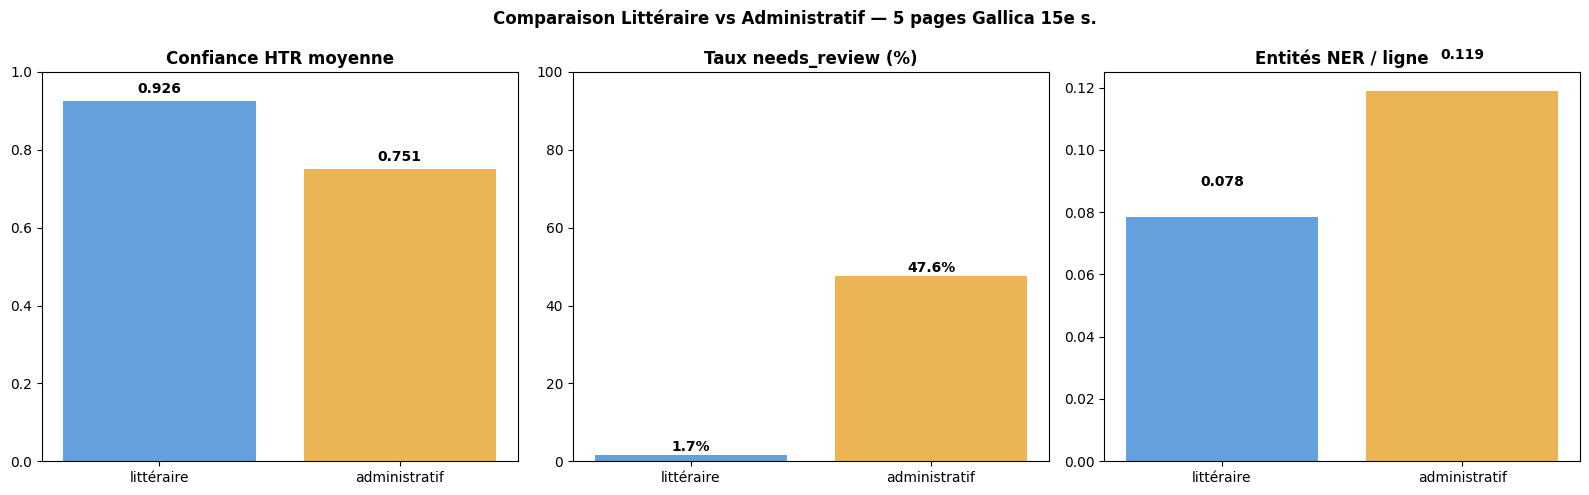


✅ rapport_comparatif_final.json sauvegardé
✅ comparaison_litteraire_admin.png sauvegardé


In [ ]:
print("="*60)
print("  RÉSULTATS COMPARATIFS — LITTÉRAIRE vs ADMINISTRATIF")
print("="*60)

stats_htr = df.groupby("type_document").agg(
    n_lignes     = ("confidence","count"),
    conf_moyenne = ("confidence","mean"),
    conf_mediane = ("confidence","median"),
    conf_min     = ("confidence","min"),
    taux_review  = ("needs_review","mean"),
).round(4)

print("\n[HTR — Confiance de transcription]")
print(stats_htr.to_string())

print("\n[NER — Entités détectées]")
for td in ["littéraire","administratif"]:
    recs = [r for r in ner_records if r["type_document"]==td]
    n_ents = sum(1 for r in recs for l in r["ner_labels"] if l!="O")
    print(f"  {td:14s} : {n_ents} entités / {len(recs)} lignes = {n_ents/max(len(recs),1):.3f}/ligne")

print("\n[Relations extraites]")
for td in ["littéraire","administratif"]:
    rels = [r for r in relations if r["type_document"]==td]
    print(f"  {td:14s} : {len(rels)} relations")

# Graphiques comparatifs
fig, axes = plt.subplots(1,3,figsize=(16,5))
types = ["littéraire","administratif"]
colors = ["#4A90D9","#E8A838"]

# 1. Confiance HTR
confs = [stats_htr.loc[t,"conf_moyenne"] if t in stats_htr.index else 0 for t in types]
axes[0].bar(types, confs, color=colors, alpha=0.85)
axes[0].set_title("Confiance HTR moyenne", fontweight="bold")
axes[0].set_ylim(0,1)
for i,v in enumerate(confs): axes[0].text(i,v+0.02,f"{v:.3f}",ha="center",fontweight="bold")

# 2. Taux needs_review
reviews = [stats_htr.loc[t,"taux_review"]*100 if t in stats_htr.index else 0 for t in types]
axes[1].bar(types, reviews, color=colors, alpha=0.85)
axes[1].set_title("Taux needs_review (%)", fontweight="bold")
axes[1].set_ylim(0,100)
for i,v in enumerate(reviews): axes[1].text(i,v+1,f"{v:.1f}%",ha="center",fontweight="bold")

# 3. Entités par ligne
ents = []
for td in types:
    recs = [r for r in ner_records if r["type_document"]==td]
    n_ents = sum(1 for r in recs for l in r["ner_labels"] if l!="O")
    ents.append(n_ents/max(len(recs),1))
axes[2].bar(types, ents, color=colors, alpha=0.85)
axes[2].set_title("Entités NER / ligne", fontweight="bold")
for i,v in enumerate(ents): axes[2].text(i,v+0.01,f"{v:.3f}",ha="center",fontweight="bold")

plt.suptitle("Comparaison Littéraire vs Administratif — 5 pages Gallica 15e s.",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{BASE}/comparaison_litteraire_admin.png", dpi=150, bbox_inches="tight")
plt.show()

rapport_final = {
    "htr_par_type":       stats_htr.to_dict(),
    "ner_par_type":       {td:{"n_entites":sum(1 for r in [x for x in ner_records if x["type_document"]==td]
                               for l in r["ner_labels"] if l!="O")} for td in types},
    "relations_par_type": {td:len([r for r in relations if r["type_document"]==td]) for td in types},
}
with open(f"{BASE}/rapport_comparatif_final.json","w",encoding="utf-8") as f:
    json.dump(rapport_final, f, indent=2, ensure_ascii=False, default=str)
print("\n✅ rapport_comparatif_final.json sauvegardé")
print("✅ comparaison_litteraire_admin.png sauvegardé")

## 10. Tests pytest + CONVENTIONS_NLP.md
Documentation et tests requis par les consignes.

In [ ]:
# ── Génération de CONVENTIONS_NLP.md ─────────────────────────────────────────
conventions = '''# CONVENTIONS_NLP.md
## Pipeline NLP — Manuscrits médiévaux 15e siècle
### Projet HETIC MD5 2026

---

## 1. Schéma BIO

Nous utilisons le schéma **BIO (Beginning-Inside-Outside)** standard :
- `B-TYPE` : premier token d'une entité de type TYPE
- `I-TYPE` : token suivant dans la même entité (non utilisé ici car entités mono-token)
- `O` : token hors entité

**Pourquoi BIO et pas BIOES ?** Notre gazetier ne produit que des entités mono-token,
donc I- et E- ne sont jamais utilisés. BIO suffit et reste compatible avec seqeval/CoNLL-2003.

## 2. Types d'entités

| Type  | Description                        | Corpus          |
|-------|------------------------------------|-----------------|
| PER   | Personnages nommés                 | Littéraire      |
| TITLE | Titres nobiliaires/religieux       | Littéraire + Admin |
| LOC   | Lieux (villes, régions)            | Administratif   |
| DATE  | Dates et fêtes liturgiques         | Administratif   |
| ORG   | Institutions (chancellerie, etc.)  | Administratif   |

## 3. Alignement subwords (point critique)

Lors du fine-tuning CamemBERT-LoRA, les tokens BIO doivent être alignés sur les subwords.
**Stratégie first-token** : seul le premier subword d'un mot reçoit l'étiquette réelle.
Les subwords suivants reçoivent `-100` (ignorés par la CrossEntropyLoss de PyTorch).

```python
# Exemple : "mabile" → ["▁mab", "ile"]
# Labels   : [B-PER,   -100  ]
```

Référence : `align_labels_to_subwords()` dans le notebook.

## 4. Normalisation

### Règles déterministes (dans l'ordre d'application)
1. Unicode NFD (décomposition des caractères composés)
2. q̃ → que (avant la règle nasale car q n'est pas une voyelle)
3. Tilde nasale + assimilation contextuelle (m/n selon consonne suivante)
4. ꝯ → con/com (même règle d'assimilation)
5. Symboles directs : ⁊→et, ꝫ→et, ꝭ→est, ꝟ→ver
6. Symboles ambigus (flaggés) : ꝑ→par, ꝕ→pre
7. u/v contextuel (v en initiale devant voyelle, i exclu pour les diphtongues ui)
8. i/j contextuel (j en initiale devant voyelle)
9. Unicode NFC (recomposition)

### Cas non résolus (flaggés dans ambiguites[])
- Accent combinant U+0301 : sens variable selon le mot
- Tilde verticale U+033E : troncation ambiguë (fouchier/foucher/etc.)

## 5. Correction guidée par confiance

Seuil : `char_confidence < 0.70` → token candidat à correction.
Modèle : CamemBERT MLM (Masked Language Model) — `almanach/camembert-base`.
Stratégie : masquage du token incertain, évaluation des top-k candidats dans le contexte.

## 6. CER relatif

Sans vérité terrain, on mesure le **CER relatif** :
- Brut → normalisé : impact des règles de normalisation
- Normalisé → corrigé MLM : impact de la correction guidée

## 7. Modèle NER

Modèle de base : `pjox/dalembert-classical-fr-ner` (moyen français, Hugging Face).
Fallback : `almanach/camembert-base`.
Fine-tuning : LoRA r=8 sur couches query+value, 15 epochs, lr=2e-4.
Évaluation : seqeval F1 micro + F1 par type d'entité.

## 8. Reproductibilité

Seeds fixées : `random.seed(42)`, `torch.manual_seed(42)`, `np.random.seed(42)`.
Test set scellé par SHA-256 dès le début du pipeline.
Split stratifié par type de document (littéraire/administratif).
'''

with open(f"{BASE}/CONVENTIONS_NLP.md","w",encoding="utf-8") as f:
    f.write(conventions)
print("✅ CONVENTIONS_NLP.md sauvegardé — Drive")

✅ CONVENTIONS_NLP.md sauvegardé — Drive


In [ ]:
# ── Tests pytest ─────────────────────────────────────────────────────────────
# 2 tests requis par les consignes :
# 1. Validation du schéma JSON du data contract
# 2. La normalisation ne dégrade pas le CER sur un échantillon de référence

test_code = '''
import pytest, json, re, unicodedata
from pathlib import Path

# ── Test 1 : Validation du schéma JSON ────────────────────────────────────────
def test_schema_json_data_contract():
    """Le JSON produit par le pipeline CV doit respecter le schéma obligatoire."""
    import jsonschema
    SCHEMA = {
        "type": "array",
        "items": {
            "type": "object",
            "required": ["image","transcriptions"],
            "properties": {
                "image": {"type":"string"},
                "transcriptions": {
                    "type":"array",
                    "items": {
                        "type":"object",
                        "required":["zone_id","bbox","texte","confidence","char_confidences","needs_review"],
                    }
                }
            }
        }
    }
    # Données de test minimales valides
    data_valide = [{
        "image": "/path/to/image.jpg",
        "nb_zones": 2,
        "transcriptions": [{
            "zone_id": 0,
            "bbox": [0,0,100,50],
            "class_name": "DefaultLine",
            "texte": "et si me sui mors a mes mains",
            "confidence": 0.95,
            "char_confidences": [0.99]*30,
            "needs_review": False,
        }]
    }]
    jsonschema.validate(data_valide, SCHEMA)  # ne doit pas lever d'exception

    # Données invalides (champ manquant)
    data_invalide = [{"image":"test.jpg"}]
    with pytest.raises(jsonschema.ValidationError):
        jsonschema.validate(data_invalide, SCHEMA)

    print("✅ Test 1 passé : schéma JSON valide")


# ── Test 2 : La normalisation ne dégrade pas le CER ───────────────────────────
def test_normalisation_ne_degrade_pas_cer():
    """
    Sur un petit échantillon de référence, la normalisation doit
    réduire ou maintenir le CER, pas l'augmenter.
    Référence humaine : paires (brut, correct) connues.
    """
    # Paires de référence : (texte brut HTR, forme correcte attendue)
    PAIRES_REFERENCE = [
        ("grãt merci",          "grant merci"),      # tilde nasale
        ("q̃ il vousist",       "que il vousist"),    # q tilde
        ("⁊ si coment",         "et si coment"),      # tironien
        ("ꝯme il dist",         "come il dist"),      # con abrégé
        ("uenir a lui",         "venir a lui"),        # u→v
        ("ioie et leece",       "joie et leece"),     # i→j
    ]

    def cer(ref, hyp):
        if not ref: return 0.0
        ref, hyp = list(ref), list(hyp)
        m, n = len(ref), len(hyp)
        dp = [[0]*(n+1) for _ in range(m+1)]
        for i in range(m+1): dp[i][0] = i
        for j in range(n+1): dp[0][j] = j
        for i in range(1,m+1):
            for j in range(1,n+1):
                if ref[i-1]==hyp[j-1]: dp[i][j]=dp[i-1][j-1]
                else: dp[i][j]=1+min(dp[i-1][j],dp[i][j-1],dp[i-1][j-1])
        return dp[m][n]/max(m,1)

    def _consonne_assimilee(suite):
        return 'm' if suite[:1].lower() in ('p','b','m') else 'n'

    def normaliser_simple(texte):
        t = unicodedata.normalize("NFD", texte)
        t = re.sub(r'[qQ]\\u0303', 'que', t)
        t = re.sub(r'([aeiouyAEIOUY])\\u0303(\\w*)',
                   lambda m: m.group(1)+_consonne_assimilee(m.group(2))+m.group(2), t)
        t = re.sub(r'ꝯ(\\w*)',
                   lambda m: ('com' if _consonne_assimilee(m.group(1))=='m' else 'con')+m.group(1), t)
        t = t.replace("⁊","et")
        t = unicodedata.normalize("NFC", t)
        t = re.sub(r'\\buu','uv',t)
        t = re.sub(r'\\bu(?=[aeouyéèê])','v',t)
        t = re.sub(r'\\bi(?=[aeouyéèê])','j',t)
        return t

    for brut, correct in PAIRES_REFERENCE:
        normalise = normaliser_simple(brut)
        cer_avant = cer(correct, brut)
        cer_apres = cer(correct, normalise)
        assert cer_apres <= cer_avant + 0.05, (
            f"Normalisation dégrade le CER : {brut!r} → {normalise!r} "
            f"(attendu {correct!r}) : {cer_avant:.3f} → {cer_apres:.3f}"
        )

    print("✅ Test 2 passé : normalisation ne dégrade pas le CER")


if __name__ == "__main__":
    test_schema_json_data_contract()
    test_normalisation_ne_degrade_pas_cer()
    print("\n✅ Tous les tests passés !")
'''

with open(f"{BASE}/test_nlp_pipeline.py","w",encoding="utf-8") as f:
    f.write(test_code)
print("✅ test_nlp_pipeline.py sauvegardé — Drive")
print("\nPour lancer les tests dans Colab :")
print("  !pip install pytest -q")
print(f"  !python -m pytest {BASE}/test_nlp_pipeline.py -v")

✅ test_nlp_pipeline.py sauvegardé — Drive

Pour lancer les tests dans Colab :
  !pip install pytest -q
  !python -m pytest /content/drive/MyDrive/projet_HTR/test_nlp_pipeline.py -v


In [ ]:
# ── Lancement des tests ───────────────────────────────────────────────────────
!pip install pytest -q
import subprocess
result = subprocess.run(
    ["python", "-m", "pytest", f"{BASE}/test_nlp_pipeline.py", "-v", "--tb=short"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content
plugins: anyio-4.14.0, typeguard-4.5.2, langsmith-0.9.1
collecting ... collected 0 items / 1 error

==================================== ERRORS ====================================
________ ERROR collecting drive/MyDrive/projet_HTR/test_nlp_pipeline.py ________
/usr/local/lib/python3.12/dist-packages/_pytest/python.py:498: in importtestmodule
    mod = import_path(
/usr/local/lib/python3.12/dist-packages/_pytest/pathlib.py:587: in import_path
    importlib.import_module(module_name)
/usr/lib/python3.12/importlib/__init__.py:90: in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
<frozen importlib._bootstrap>:1387: in _gcd_import
    ???
<frozen importlib._bootstrap>:1360: in _find_and_load
    

---
## Récapitulatif des livrables

Tous dans `/content/drive/MyDrive/projet_HTR/` :

**Données**
- `corpus_normalise_taln.json` — data contract NLP (texte brut + normalisé + corrigé MLM)
- `corpus_ner.conll` — annotations NER + POS (CoNLL-2003)
- `relations.json` — triplets de relations
- `triplets_a_valider.json` — à remplir manuellement
- `precision_report.json` — précision après validation

**Modèles**
- `ner_medieval_lora/` — modèle NER fine-tuné (LoRA)
- `ner_training_log.json` — courbe de loss + métriques F1

**Graphe & Export**
- `knowledge_graph.jsonld` — graphe JSON-LD
- `graphe_connaissances.png` — visualisation
- `tei_output/*.xml` — export TEI-XML par document

**Évaluation**
- `rapport_eda.json` — analyse exploratoire
- `rapport_comparatif_final.json` — littéraire vs administratif
- `comparaison_litteraire_admin.png` — graphiques comparatifs
- `test_set_sha256.txt` — sceau SHA-256 du test set

**Documentation & Tests**
- `CONVENTIONS_NLP.md` — documentation des choix NLP
- `test_nlp_pipeline.py` — 2 tests pytest